# (A) Candidate Datasets

#### 1. Intrusion detection evaluation dataset (CIC-IDS2017) https://www.unb.ca/cic/datasets/ids-2017.html

*   **Course Topic:** Anomaly Detection (network intrusion detection)
*   **Potential Beyond-Course:** auto-encoders, transformer models, deep AI models
*   **Dataset Size/Structure**: Around 51 Gigabytes of network traffic in PCAP format, seperated by weekdays of network flow structure.
*   **Data Types:** packet counts, bytes transferred, flow duration, protocol type, flags, timestamps
*   **Target Variables:** Multi-class labeling on anomalies ("Web based, Brute force, DoS, DDoS, Infiltration, Heart-bleed, Bot and Scan" )
*   **Licensing:** Publicly available for research, paper citation required (cited below in collaboration section)

#### 2. NASA SMAP/MSL Telemetry Datasets https://github.com/khundman/telemanom

*   **Course Topic:** Anomaly Detection
*   **Potential Beyond-Course:** Prediction/forecast-based anomaly detection with NNs like LSTM, attention/transformer models.
*   **Dataset Size/Structure**: Around 500K telemetry points across 82 unique telemetry channels, CSV format.
*   **Data Types:** timestamps, telemetry data (temp/volts/radiation/etc), command sequences, for anomaly files: just anomaly sequences and MSL/SMAP.
*   **Target Variables:** Binary anomaly indicators and known anomaly periods
*   **Licensing:** Data is publicly available from NASA.

#### 3. Quantum Mechanics 9 https://quantum-machine.org/

*   **Course Topic:** Graph mining, community detection, centrality, subgraphs
*   **Potential Beyond-Course:** Graph neural networks (GCN/GAT) for prediction of properties
*   **Dataset Size/Structure**: Around 134K small molecules, with up to 9 heavy atoms, provided as graph objects OR CSV w/ processed features
*   **Data Types:** Node features (atom type/charge), edge features (bond type), 3D coordinates, 19 quantum properties
*   **Target Variables:** 19 regression targets from the quantum properties, e.g. HOMO/LUMO energies and dipole moment
*   **Licensing:** Public domain, paper citation requested (cited in collaboration section)



#(B) Comparative Analysis
| Dimension              | CIC-IDS2017 (Cybersecurity)                                      | NASA SMAP/MSL (Space)                                            | QM9 (Quantum/AI)                                                 |
|------------------------|------------------------------------------------------------------|------------------------------------------------------------------|------------------------------------------------------------------|
| Supported data mining tasks | Anomaly detection (course)<br>deep autoencoders/GANs (beyond)   | Anomaly/streaming (course)<br>LSTM/Transformer forecasting (beyond) | Graph mining/community detection (course)<br>GNNs (beyond)      |
| Data quality issues    | Class imbalance (attacks << benign)<br>some duplicated flows<br>generated (not fully real-world) traffic | Telemetry noise<br>high-dimensional multivariate correlations<br>occasional missing points | Restricted to small molecules (≤9 heavy atoms)<br>filtered for stability<br>no large/complex molecules |
| Algorithmic feasibility | Large but feature-based<br>standard anomaly algos (isolation forest, one-class SVM) run easily<br>deep models need GPU/sub-sampling | Moderate size<br>streaming algos and LSTMs feasible on laptop<br>Transformers possible with subsets | 134k graphs manageable<br>classic graph algos (Louvain, PageRank) fast<br>GNN training feasible on modest GPU |
| Bias considerations    | Generated attack profiles may over-represent certain attacks<br>limited network topologies | Specific to two spacecraft systems – may not generalize to other satellites/rovers | Only stable small organic molecules<br>under-represents larger/biologically relevant compounds |
| Ethical considerations | Network data is anonymized, but real-world use could involve privacy<br>no direct harm in analysis | NASA public data; low risk<br>analysis could improve spacecraft safety | Pure computational chemistry<br>no privacy or social power issues |

# (C) Dataset Selection

I choose the dataset QM9

Reasons:
* Supports direct graph mining concepts from course learned early on, such as centrality, community detection, subgraphs, and even pagerank.
* Provides the opportunity for beyond the course techniques with more unique graph neural network algorithms like GCN/GAT, which is personally preferable than other datasets whos opportunities were somwhat limited to Attention models/LLMs.
* Allows for the exploration of machine learning and its understanding/prediction of quantum properties that were computed via DFT (density functional theory)
* Manageable size of ~134k nodes for ease of use in colab notebooks, no need for sampling.

Trade-offs:
* Primarily supervised regression tasks, not much opportunity for unsupervised course topics like anomaly detection or clustering.
* Molecules are restricted to a smaller subset of organic compounds, with up to only 9 heavy atoms (CONF+H), which limits the generalizability for larger chemical spaces.

# (D) EDA

In [3]:
import os
from load_qm9 import load_qm9_dataset

# Ensure qm9_data directory exists (for first-time cloners)
data_dir = os.path.abspath('qm9_data')
os.makedirs(data_dir, exist_ok=True)

print("Loading QM9 dataset...")
dataset_pyg = load_qm9_dataset(root=data_dir)
print(f"✓ Successfully loaded {len(dataset_pyg)} molecules!")
print(f"Example data object:\n{dataset_pyg[0]}")

Loading QM9 dataset...


Extracting /home/m3d1/Projects/Analysis-of-QM9/qm9_data/raw/qm9.zip
Processing...
100%|██████████| 133885/133885 [01:13<00:00, 1818.52it/s]
Done!


✓ Successfully loaded 130831 molecules!
Example data object:
Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])


In [2]:
# --- Imports for EDA ---
import torch
from torch_geometric.utils import to_networkx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
import py3Dmol
from IPython.display import display, Image

# Set style for nicer plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# --- Basic Data Statistics ---
num_nodes = [data.num_nodes for data in dataset_pyg]  # Total atoms (incl. H)
num_heavy = [(data.z > 1).sum().item() for data in dataset_pyg]  # Heavy atoms (C,O,N,F)
atomic_nums = torch.cat([data.z for data in dataset_pyg]).numpy()

# Target properties (focus on first 12 standard regression targets)
# Indices: 0: mu (dipole), 1: alpha, 2: homo, 3: lumo, 4: gap, 5: r2, 6: zpve,
# 7: U0, 8: U, 9: H, 10: G, 11: Cv
target_names = ['mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'U0', 'U', 'H', 'G', 'Cv']
targets = torch.cat([data.y[:, :12] for data in dataset_pyg]).numpy()

print("\n--- Data Basics ---")
print(f"Average atoms per molecule: {np.mean(num_nodes):.2f} (range {min(num_nodes)}–{max(num_nodes)})")
print(f"Average heavy atoms: {np.mean(num_heavy):.2f} (max 9 as expected)")
atom_counts = np.unique(atomic_nums, return_counts=True)
atom_symbols = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}
print("Atom type distribution:")
for z, count in zip(atom_counts[0], atom_counts[1]):
    print(f"  {atom_symbols[z]}: {count:,} ({count/len(atomic_nums)*100:.1f}%)")


--- Data Basics ---
Average atoms per molecule: 18.03 (range 3–29)
Average heavy atoms: 8.80 (max 9 as expected)
Atom type distribution:
  H: 1,208,486 (51.2%)
  C: 831,925 (35.3%)
  N: 132,498 (5.6%)
  O: 183,265 (7.8%)
  F: 3,036 (0.1%)


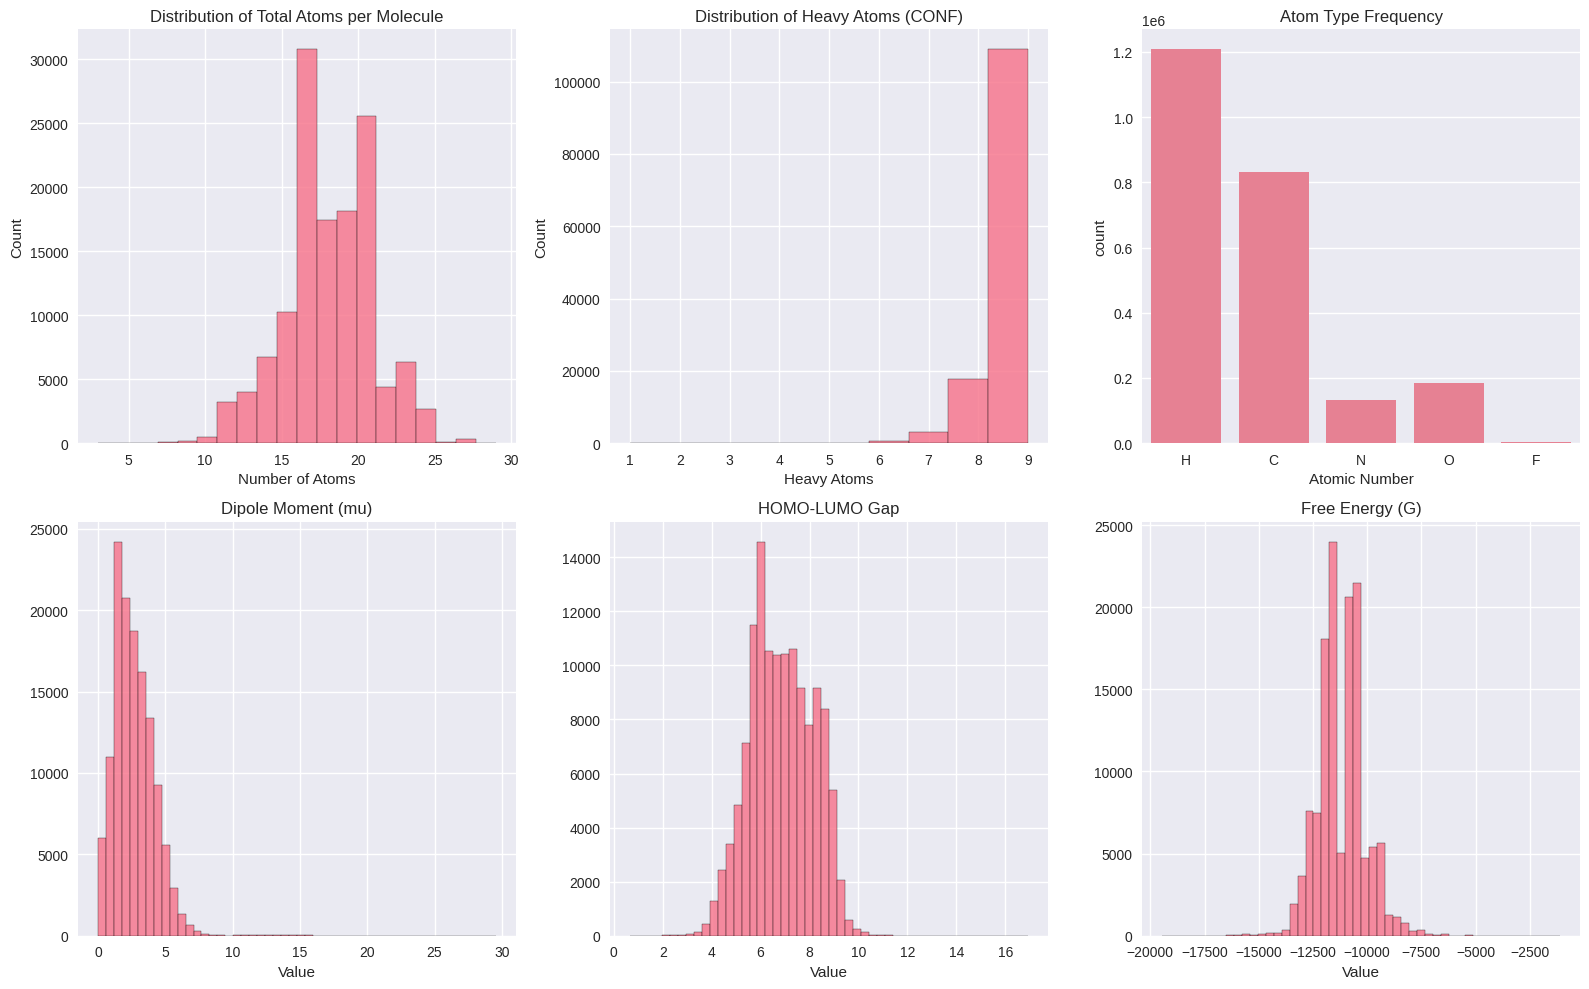

In [ ]:
# --- Distribution Plots ---
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.hist(num_nodes, bins=20, edgecolor='black', alpha=0.8)
plt.title('Distribution of Total Atoms per Molecule')
plt.xlabel('Number of Atoms')
plt.ylabel('Count')

plt.subplot(2, 3, 2)
plt.hist(num_heavy, bins=10, edgecolor='black', alpha=0.8)
plt.title('Distribution of Heavy Atoms (CONF)')
plt.xlabel('Heavy Atoms')
plt.ylabel('Count')

plt.subplot(2, 3, 3)
sns.countplot(x=atomic_nums, order=[1,6,7,8,9])
plt.title('Atom Type Frequency')
plt.xlabel('Atomic Number')
plt.xticks(ticks=[0,1,2,3,4], labels=['H', 'C', 'N', 'O', 'F'])

plt.subplot(2, 3, 4)
plt.hist(targets[:, 0], bins=50, edgecolor='black', alpha=0.8)
plt.title('Dipole Moment (mu)')
plt.xlabel('Value')

plt.subplot(2, 3, 5)
plt.hist(targets[:, 4], bins=50, edgecolor='black', alpha=0.8)
plt.title('HOMO-LUMO Gap')
plt.xlabel('Value')

plt.subplot(2, 3, 6)
plt.hist(targets[:, 10], bins=50, edgecolor='black', alpha=0.8)
plt.title('Free Energy (G)')
plt.xlabel('Value')

plt.tight_layout()
plt.show()


Sample 2D Molecules:


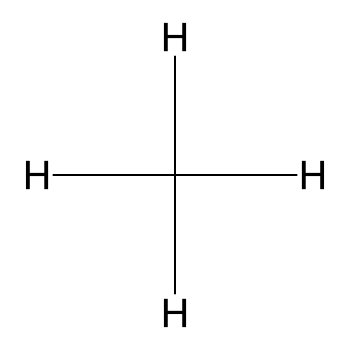

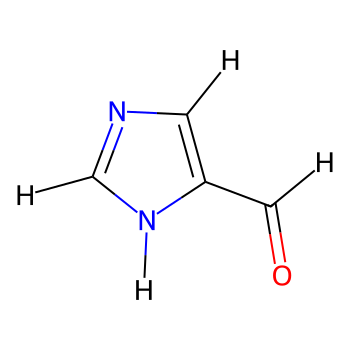

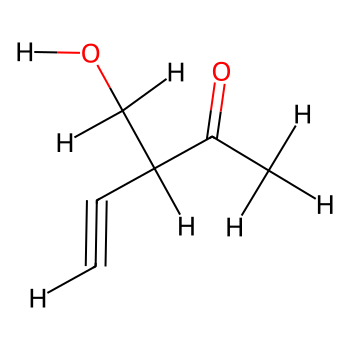


Grid of 8 Random Molecules:


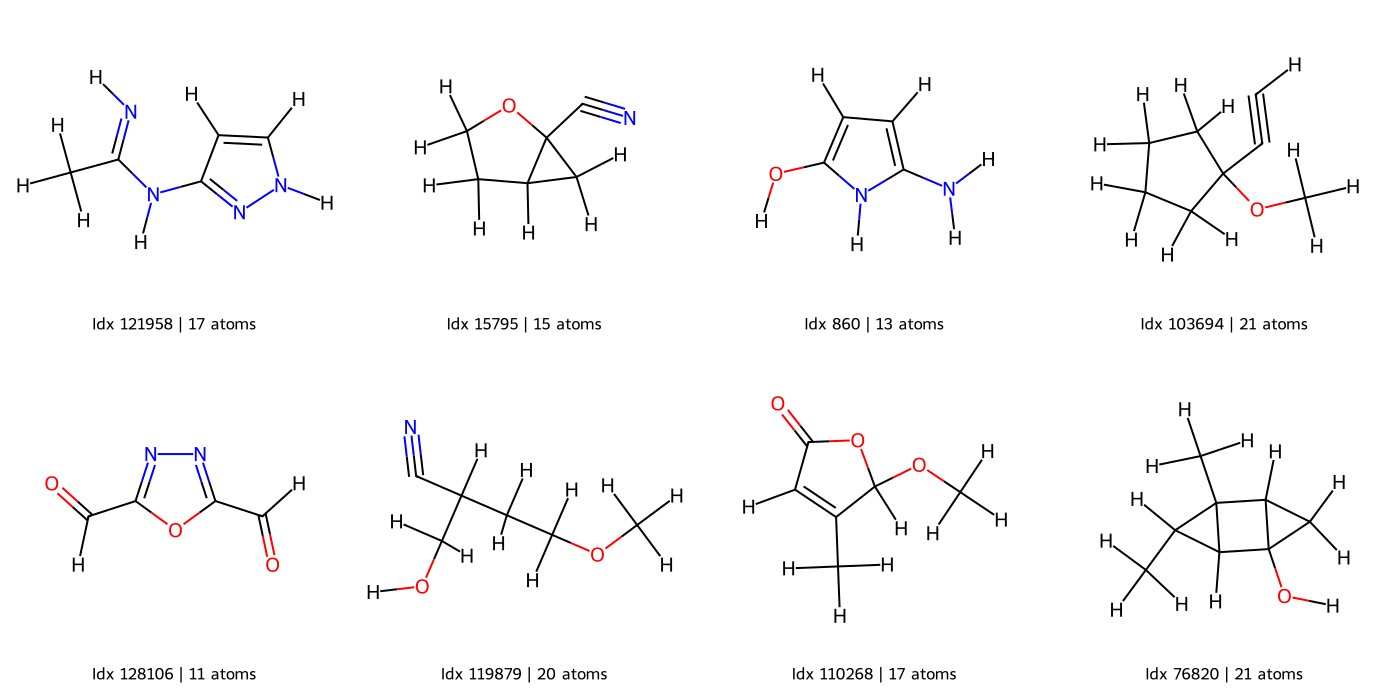


Raw Graph Examples:


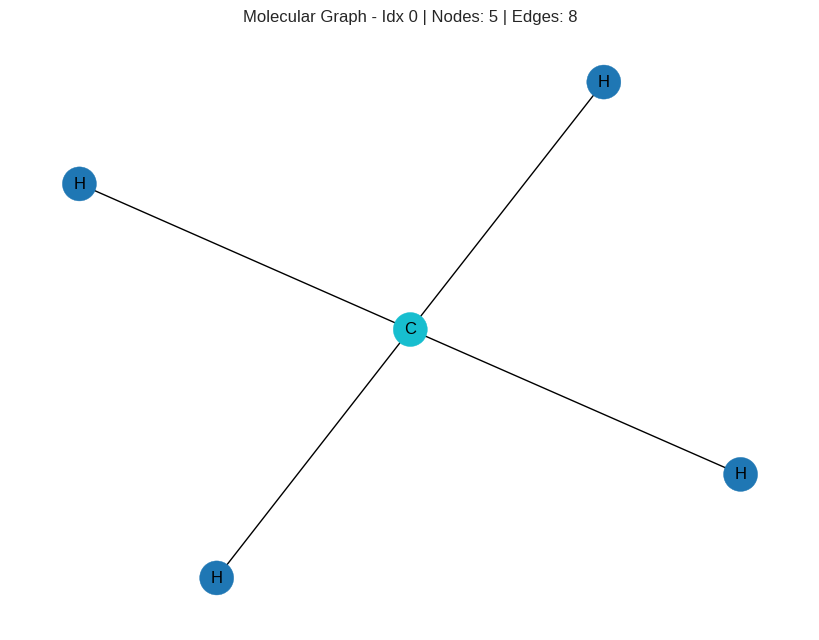

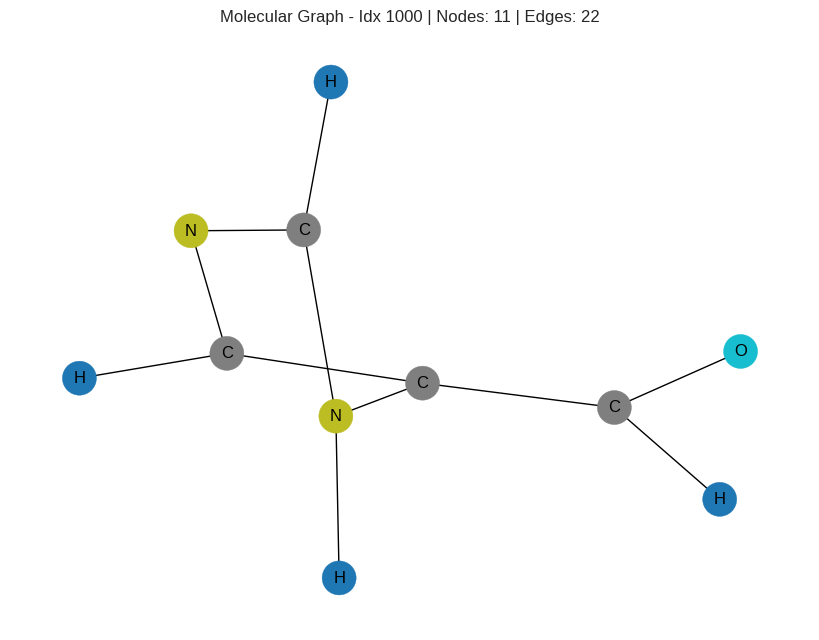


Interactive 3D Example of CH₄:


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# --- Molecule Visualization Functions ---
def pyg_to_rdkit_mol(data):
    """Convert PyG data to RDKit molecule with 2D/3D coordinates"""
    mol = Chem.RWMol()
    symbol_map = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F'}
    for z in data.z:
        mol.AddAtom(Chem.Atom(symbol_map[int(z.item())]))

    if data.edge_attr is not None:
        bond_types = data.edge_attr[:, :4].argmax(dim=1)
        bond_map = {0: Chem.BondType.SINGLE, 1: Chem.BondType.DOUBLE,
                    2: Chem.BondType.TRIPLE, 3: Chem.BondType.AROMATIC}
        seen = set()
        for (i, j), bt_idx in zip(data.edge_index.t().tolist(), bond_types):
            bond = (min(i,j), max(i,j))
            if bond not in seen:
                mol.AddBond(int(i), int(j), bond_map[int(bt_idx.item())])
                seen.add(bond)

    mol = mol.GetMol()
    # Add 3D conformer
    conf = Chem.Conformer(data.pos.shape[0])
    for k in range(data.pos.shape[0]):
        conf.SetAtomPosition(k, data.pos[k].tolist())
    mol.AddConformer(conf)
    # Generate clean 2D layout
    AllChem.Compute2DCoords(mol)
    try:
        Chem.SanitizeMol(mol)
    except:
        pass
    return mol

def visualize_2d(idx, size=(350, 350)):
    """Display a single molecule in 2D"""
    mol = pyg_to_rdkit_mol(dataset_pyg[idx])
    return Draw.MolToImage(mol, size=size)

def grid_visualize_2d(indices, cols=4):
    """Display a grid of molecules in 2D"""
    mols = [pyg_to_rdkit_mol(dataset_pyg[i]) for i in indices]
    legends = [f"Idx {i} | {dataset_pyg[i].num_nodes} atoms" for i in indices]
    return Draw.MolsToGridImage(mols, molsPerRow=cols, subImgSize=(350, 350), legends=legends)

def visualize_3d(idx):
    """Interactive 3D visualization"""
    mol = pyg_to_rdkit_mol(dataset_pyg[idx])
    mb = Chem.MolToMolBlock(mol, confId=0)
    view = py3Dmol.view(width=600, height=400)
    view.addModel(mb, 'mol')
    view.setStyle({'stick': {'colorscheme': 'jmol'}})
    view.setBackgroundColor('white')
    view.addLabel(f"Idx {idx} | {dataset_pyg[idx].num_nodes} atoms", {'fontSize': 14})
    view.zoomTo()
    view.show()

def visualize_graph(idx):
    """Raw graph visualization using NetworkX"""
    data = dataset_pyg[idx]
    G = to_networkx(data, to_undirected=True)
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_color=data.z, cmap=plt.cm.tab10, node_size=600,
            with_labels=True, labels={i: atom_symbols[int(data.z[i])] for i in range(data.num_nodes)})
    plt.title(f"Molecular Graph - Idx {idx} | Nodes: {data.num_nodes} | Edges: {data.num_edges}")
    plt.show()

# --- Example Visualizations ---
print("\nSample 2D Molecules:")
display(visualize_2d(0))
display(visualize_2d(1000))
display(visualize_2d(10000))

print("\nGrid of 8 Random Molecules:")
np.random.seed(42)
random_idxs = np.random.randint(0, len(dataset_pyg), 8).tolist()
display(grid_visualize_2d(random_idxs))

print("\nRaw Graph Examples:")
visualize_graph(0)
visualize_graph(1000)

print("\nInteractive 3D Example of CH₄:")
visualize_3d(0)

In [ ]:
# --- Data Quality, Cleaning, and Bias Checks ---
print("\n--- Data Quality & Cleaning ---")
print("Missing values in targets:", np.isnan(targets).any())  # Expected: False
print("Disconnected graphs (sample check):", any(data.num_edges == 0 for data in dataset_pyg[:1000]))
# QM9 is extremely clean — no missing data, pre-filtered for stability.

print("\n--- Bias Considerations ---")
print("- Restricted to small organic molecules (≤9 heavy atoms: C, H, O, N, F only)")
print("- Strong selection bias: only stable, singlet-state, neutral molecules")
print("- All properties computed at consistent DFT level (B3LYP/6-31G(2df,p)) — no experimental variance")
print("- Under-represents larger molecules, charged species, or metals")


--- Data Quality & Cleaning ---
Missing values in targets: False
Disconnected graphs (sample check): False

--- Bias Considerations ---
- Restricted to small organic molecules (≤9 heavy atoms: C, H, O, N, F only)
- Strong selection bias: only stable, singlet-state, neutral molecules
- All properties computed at consistent DFT level (B3LYP/6-31G(2df,p)) — no experimental variance
- Under-represents larger molecules, charged species, or metals


# (E) Initial Insights and Direction
**Observation**:
Most molecules have 8-9 heavy atoms, with significant dropoff at 7 and less, of these heavy atoms the most dominant is Carbon. Target properties such as free energy show multimodal distribution, which is a reflection of chemical families. Overall the graphs are also very small in width/diameter, very densely concentrated together.

**Hypothesis**:
Graph mining techniques (community/centrality) will capture basic patterns, structural motifs, and will provide some insight on behavior of the molecules; however they will miss more nuanced quantum effects that graph neural network algorithms can learn by design.

**RQ**:
* How do frequent patterns in graph mining techniques correlate to quantum properties compared to GNN (Graph Neural Network) predictions?
* Can community detection on molecular graphs reveal any chemical functional groups missed by atom-type counts?
* Do GNNs outperform classic graph mining techniques on regression tasks (e.g. predicting HOMO/LUMO gap)?

# (F) GitHub Portfolio Building
https://github.com/EmeryJJ/Analysis-of-QM9

On my honor, I declare the following resources:
1. Collaborators:
- N/A

2. Web sources:
- https://github.com/khundman/telemanom

3. AI Tools:
- Grok: I prompted the AI to fill out the table in part (B), To perform an EDA on the QM9 dataset on part (D). Lastly I asked for some ideas for RQ's and used some parts of them.

4. Citations:

- **CICIDS2017 paper**

- Iman Sharafaldin, Arash Habibi Lashkari, and Ali A. Ghorbani, “Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization”, 4th International Conference on Information Systems Security and Privacy (ICISSP), Portugal, January 2018.

- **QM9 papers**

- L. Ruddigkeit, R. van Deursen, L. C. Blum, J.-L. Reymond, Enumeration of 166 billion organic small molecules in the chemical universe database GDB-17, J. Chem. Inf. Model. 52, 2864–2875, 2012.
- R. Ramakrishnan, P. O. Dral, M. Rupp, O. A. von Lilienfeld, Quantum chemistry structures and properties of 134 kilo molecules, Scientific Data 1, 140022, 2014